# LLM Code Generation Benchmark Analysis
## summary.json 기반 행동/문제 단위 성공률 분석

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

## 0. 경로 설정 및 데이터 로드

In [2]:
# ── 필요시 ROOT_DIR 수정 ──────────────────────────────────────
ROOT_DIR = Path("../results")
# ─────────────────────────────────────────────────────────────

# 폴더명 -> 표시 이름 매핑
MODEL_DISPLAY = {
    "phi35mini"   : "Phi-3.5-Mini",
    "qwen7bcoder" : "Qwen2.5-Coder-7B",
}
DATASET_DISPLAY = {
    "humaneval": "HumanEval",
    "mbpp"     : "MBPP",
}
METHOD_DISPLAY = {
    "repair_loop"          : "Repair",
    "code_then_plan"       : "Planning",
    "code_then_plan_repair": "Planning_Repair",
    "policy_loop"          : "FARC",
}

def disp_model(r):   return MODEL_DISPLAY.get(r["_model"],   r["_model"])
def disp_dataset(r): return DATASET_DISPLAY.get(r["_dataset"], r["_dataset"])
def disp_method(r):  return METHOD_DISPLAY.get(r.get("method", ""), r.get("method", r["_method_dir"]))


# 전체 summary.json 자동 탐색
records = []
for model_dir in sorted(ROOT_DIR.iterdir()):
    if not model_dir.is_dir(): continue
    for dataset_dir in sorted(model_dir.iterdir()):
        if not dataset_dir.is_dir(): continue
        for method_dir in sorted(dataset_dir.iterdir()):
            summary_path = method_dir / "summary.json"
            if not summary_path.exists(): continue
            with open(summary_path, encoding="utf-8") as f:
                data = json.load(f)
            data["_model"]      = model_dir.name
            data["_dataset"]    = dataset_dir.name
            data["_method_dir"] = method_dir.name
            records.append(data)

print(f"총 {len(records)}개 summary.json 로드 완료")
for r in records:
    print(f"  {r['_model']} / {r['_dataset']} / {r['_method_dir']}  ->  method={r.get('method')}")

총 30개 summary.json 로드 완료
  llama318b / humaneval / code_then_plan  ->  method=code_then_plan
  llama318b / humaneval / code_then_plan_repair  ->  method=code_then_plan_repair
  llama318b / humaneval / proposed_v1  ->  method=policy_loop
  llama318b / humaneval / repair  ->  method=repair_loop
  llama318b / humaneval / single  ->  method=single_shot
  llama318b / mbpp / code_then_plan  ->  method=code_then_plan
  llama318b / mbpp / code_then_plan_repair  ->  method=code_then_plan_repair
  llama318b / mbpp / proposed_v1  ->  method=policy_loop
  llama318b / mbpp / repair  ->  method=repair_loop
  llama318b / mbpp / single  ->  method=single_shot
  phi35mini / humaneval / code_then_plan  ->  method=code_then_plan
  phi35mini / humaneval / code_then_plan_repair  ->  method=code_then_plan_repair
  phi35mini / humaneval / proposed_v1  ->  method=policy_loop
  phi35mini / humaneval / repair  ->  method=repair_loop
  phi35mini / humaneval / single  ->  method=single_shot
  phi35mini / mbpp / c

---
## 1. 행동(Action / Call) 단위 성공률 분석

### 1-1. Planning 행동 성공률 전체 비교

| 컬럼 | 설명 | JSON 소스 |
|---|---|---|
| Planning-used Problems | planning이 발동된 문제 수 | `planning_stats.used_plan` / `policy_stats.problem_level.plan_used_problems` |
| Planning-based Regeneration Calls | planning 재생성 호출 횟수 | `call_level.planning_cycle_count` / `policy_stats.call_level.planning_cycle_count` |
| Successful Planning Recovery | 재생성 중 코드 생성 성공 수 | `call_level.planning_code_success_count` |
| Action-level Success Rate | Successful / Regeneration Calls | 계산 |

In [3]:
def extract_planning_call(r):
    method = r.get("method", "")

    if method == "code_then_plan_repair":
        ps            = r.get("planning_stats", {})
        cl            = r.get("call_level", {})
        used_problems = ps.get("used_plan")
        regen_calls   = cl.get("planning_cycle_count", 0)
        success       = cl.get("planning_code_success_count", 0)

    elif method == "policy_loop":
        pl            = (r.get("policy_stats") or {}).get("problem_level", {})
        cl            = (r.get("policy_stats") or {}).get("call_level", {})
        used_problems = pl.get("plan_used_problems")
        regen_calls   = cl.get("planning_cycle_count", 0)
        success       = cl.get("planning_code_success_count", 0)

    else:
        return None

    rate = success / regen_calls if regen_calls else None
    return {
        "Model"                            : disp_model(r),
        "Dataset"                          : disp_dataset(r),
        "Method"                           : disp_method(r),
        "Planning-used Problems"           : used_problems,
        "Planning-based Regeneration Calls": regen_calls,
        "Successful Planning Recovery"     : success,
        "Action-level Success Rate"        : rate,
    }


df_plan_call = pd.DataFrame(
    [row for r in records if (row := extract_planning_call(r)) is not None]
)
print("[1-1] Planning 행동 성공률 전체 비교")
df_plan_call.style \
    .format({"Action-level Success Rate": "{:.2%}"}) \
    .background_gradient(subset=["Action-level Success Rate"], cmap="YlGn")

[1-1] Planning 행동 성공률 전체 비교


,Model,Dataset,Method,Planning-used Problems,Planning-based Regeneration Calls,Successful Planning Recovery,Action-level Success Rate
0,llama318b,HumanEval,Planning_Repair,105,480,39,8.12%
1,llama318b,HumanEval,FARC,111,430,36,8.37%
2,llama318b,MBPP,Planning_Repair,229,584,105,17.98%
3,llama318b,MBPP,FARC,183,465,64,13.76%
4,Phi-3.5-Mini,HumanEval,Planning_Repair,162,478,114,23.85%
5,Phi-3.5-Mini,HumanEval,FARC,117,335,78,23.28%
6,Phi-3.5-Mini,MBPP,Planning_Repair,92,384,33,8.59%
7,Phi-3.5-Mini,MBPP,FARC,75,292,17,5.82%
8,qwen25coder7b,HumanEval,Planning_Repair,49,119,34,28.57%
9,qwen25coder7b,HumanEval,FARC,33,76,21,27.63%


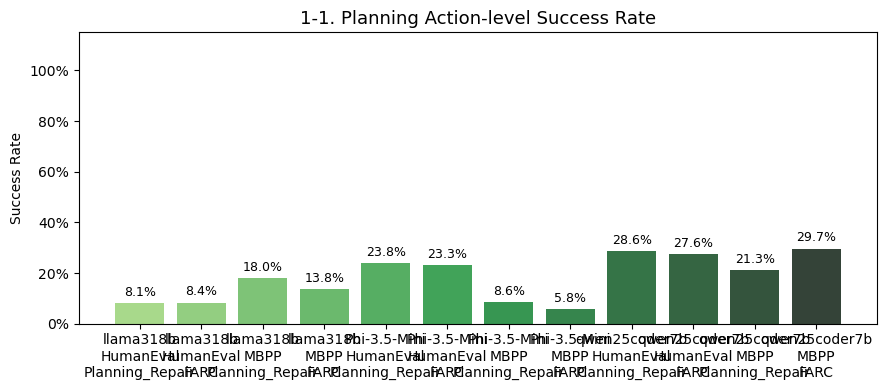

In [4]:
if not df_plan_call.empty:
    fig, ax = plt.subplots(figsize=(9, 4))
    x = df_plan_call.apply(lambda r: f"{r['Model']}\n{r['Dataset']}\n{r['Method']}", axis=1)
    bars = ax.bar(x, df_plan_call["Action-level Success Rate"],
                  color=sns.color_palette("YlGn_d", len(df_plan_call)))
    ax.bar_label(bars, fmt="{:.1%}", padding=3, fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title("1-1. Planning Action-level Success Rate", fontsize=13)
    ax.set_ylabel("Success Rate")
    plt.tight_layout()
    plt.show()
else:
    print("Planning call_level 데이터가 없습니다.")

### 1-2. Repair 행동 성공률 전체 비교

| 컬럼 | 설명 | JSON 소스 |
|---|---|---|
| Repair-used Problems | repair가 발동된 문제 수 | `planning_stats.used_repair` / `policy_stats.problem_level.repair_used_problems` |
| Repair Calls | repair 호출 총 횟수 | `call_level.repair_call_count` / `policy_stats.call_level.repair_call_count` |
| Successful Repair Recovery | repair 호출 중 성공 수 | `call_level.repair_success_count` / `repair_call_success_count` |
| Action-level Success Rate | Successful / Repair Calls | 계산 |

In [5]:
def extract_repair_call(r):
    method = r.get("method", "")

    if method == "repair_loop":
        total = r.get("total_problems", 0)
        calls = round(r.get("avg_calls", 1) * total)
        succ  = r.get("num_success", 0)
        rate  = succ / calls if calls else None
        return {
            "Model"                     : disp_model(r),
            "Dataset"                   : disp_dataset(r),
            "Method"                    : disp_method(r),
            "Repair-used Problems"      : total,
            "Repair Calls"              : calls,
            "Successful Repair Recovery": succ,
            "Action-level Success Rate" : rate,
        }

    if method == "code_then_plan_repair":
        ps    = r.get("planning_stats", {})
        cl    = r.get("call_level", {})
        used  = ps.get("used_repair")
        calls = cl.get("repair_call_count", 0)
        succ  = cl.get("repair_success_count", 0)
        rate  = succ / calls if calls else None
        return {
            "Model"                     : disp_model(r),
            "Dataset"                   : disp_dataset(r),
            "Method"                    : disp_method(r),
            "Repair-used Problems"      : used,
            "Repair Calls"              : calls,
            "Successful Repair Recovery": succ,
            "Action-level Success Rate" : rate,
        }

    if method == "policy_loop":
        pl    = (r.get("policy_stats") or {}).get("problem_level", {})
        cl    = (r.get("policy_stats") or {}).get("call_level", {})
        used  = pl.get("repair_used_problems")
        calls = cl.get("repair_call_count", 0)
        succ  = cl.get("repair_call_success_count", 0)
        rate  = cl.get("repair_call_success_rate", succ / calls if calls else None)
        return {
            "Model"                     : disp_model(r),
            "Dataset"                   : disp_dataset(r),
            "Method"                    : disp_method(r),
            "Repair-used Problems"      : used,
            "Repair Calls"              : calls,
            "Successful Repair Recovery": succ,
            "Action-level Success Rate" : rate,
        }

    return None


df_repair_call = pd.DataFrame(
    [row for r in records if (row := extract_repair_call(r)) is not None]
)
print("[1-2] Repair 행동 성공률 전체 비교")
df_repair_call.style \
    .format({"Action-level Success Rate": "{:.2%}"}) \
    .background_gradient(subset=["Action-level Success Rate"], cmap="YlOrRd")

[1-2] Repair 행동 성공률 전체 비교


,Model,Dataset,Method,Repair-used Problems,Repair Calls,Successful Repair Recovery,Action-level Success Rate
0,llama318b,HumanEval,Planning_Repair,90,441,7,1.59%
1,llama318b,HumanEval,FARC,124,546,17,3.11%
2,llama318b,HumanEval,Repair,164,2330,50,2.15%
3,llama318b,MBPP,Planning_Repair,142,479,67,13.99%
4,llama318b,MBPP,FARC,219,776,96,12.37%
5,llama318b,MBPP,Repair,257,4119,60,1.46%
6,Phi-3.5-Mini,HumanEval,Planning_Repair,82,364,1,0.27%
7,Phi-3.5-Mini,HumanEval,FARC,161,387,44,11.37%
8,Phi-3.5-Mini,HumanEval,Repair,164,3223,3,0.09%
9,Phi-3.5-Mini,MBPP,Planning_Repair,73,351,9,2.56%


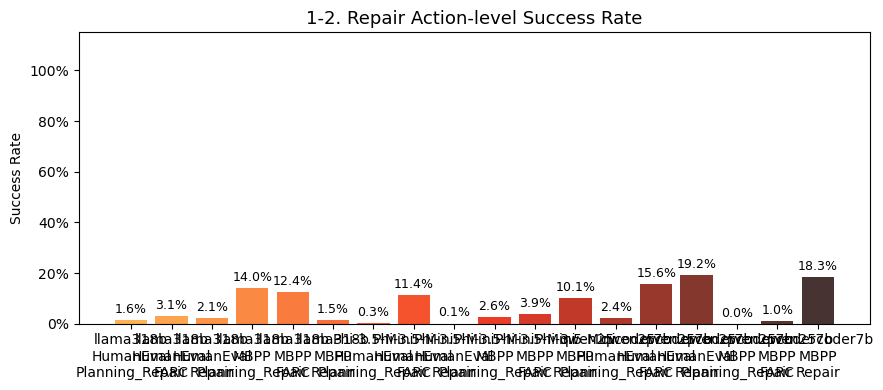

In [6]:
if not df_repair_call.empty:
    fig, ax = plt.subplots(figsize=(9, 4))
    x = df_repair_call.apply(lambda r: f"{r['Model']}\n{r['Dataset']}\n{r['Method']}", axis=1)
    bars = ax.bar(x, df_repair_call["Action-level Success Rate"],
                  color=sns.color_palette("YlOrRd_d", len(df_repair_call)))
    ax.bar_label(bars, fmt="{:.1%}", padding=3, fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title("1-2. Repair Action-level Success Rate", fontsize=13)
    ax.set_ylabel("Success Rate")
    plt.tight_layout()
    plt.show()
else:
    print("Repair call_level 데이터가 없습니다.")

---
## 2. 문제(Problem) 단위 기여도 분석

### 2-1. Planning 기여도 전체 비교

In [7]:
def extract_planning_problem(r):
    method = r.get("method", "")

    if method == "code_then_plan":
        ps = r.get("plan_stats", {})
        return {
            "Model"                      : disp_model(r),
            "Dataset"                    : disp_dataset(r),
            "Method"                     : disp_method(r),
            "Plan Used Problems"         : ps.get("used_plan"),
            "Plan Recovery Success"      : ps.get("plan_recovered"),
            "Problem-level Recovery Rate": ps.get("plan_recovery_rate"),
        }

    if method == "code_then_plan_repair":
        ps = r.get("planning_stats", {})
        return {
            "Model"                      : disp_model(r),
            "Dataset"                    : disp_dataset(r),
            "Method"                     : disp_method(r),
            "Plan Used Problems"         : ps.get("used_plan"),
            "Plan Recovery Success"      : ps.get("planning_recovered"),
            "Problem-level Recovery Rate": ps.get("planning_recovery_rate"),
        }

    if method == "policy_loop":
        pl = (r.get("policy_stats") or {}).get("problem_level", {})
        return {
            "Model"                      : disp_model(r),
            "Dataset"                    : disp_dataset(r),
            "Method"                     : disp_method(r),
            "Plan Used Problems"         : pl.get("plan_used_problems"),
            "Plan Recovery Success"      : pl.get("plan_recovered_problems"),
            "Problem-level Recovery Rate": pl.get("plan_problem_recovery_rate"),
        }

    return None


df_plan_prob = pd.DataFrame(
    [row for r in records if (row := extract_planning_problem(r)) is not None]
)
print("[2-1] Planning 기여도 전체 비교")
df_plan_prob.style \
    .format({"Problem-level Recovery Rate": "{:.2%}"}) \
    .background_gradient(subset=["Problem-level Recovery Rate"], cmap="Blues")

[2-1] Planning 기여도 전체 비교


,Model,Dataset,Method,Plan Used Problems,Plan Recovery Success,Problem-level Recovery Rate
0,llama318b,HumanEval,Planning,126,66,52.38%
1,llama318b,HumanEval,Planning_Repair,105,46,43.81%
2,llama318b,HumanEval,FARC,111,36,32.43%
3,llama318b,MBPP,Planning,231,157,67.97%
4,llama318b,MBPP,Planning_Repair,229,172,75.11%
5,llama318b,MBPP,FARC,183,64,34.97%
6,Phi-3.5-Mini,HumanEval,Planning,160,124,77.50%
7,Phi-3.5-Mini,HumanEval,Planning_Repair,162,115,70.99%
8,Phi-3.5-Mini,HumanEval,FARC,117,78,66.67%
9,Phi-3.5-Mini,MBPP,Planning,94,37,39.36%


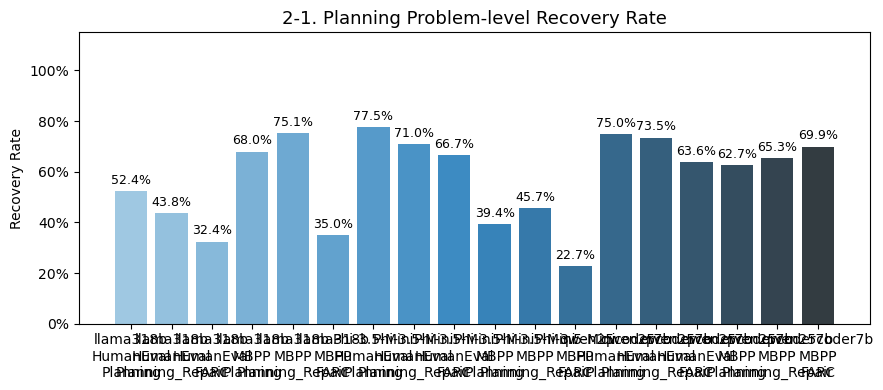

In [8]:
if not df_plan_prob.empty:
    fig, ax = plt.subplots(figsize=(9, 4))
    x = df_plan_prob.apply(lambda r: f"{r['Model']}\n{r['Dataset']}\n{r['Method']}", axis=1)
    bars = ax.bar(x, df_plan_prob["Problem-level Recovery Rate"],
                  color=sns.color_palette("Blues_d", len(df_plan_prob)))
    ax.bar_label(bars, fmt="{:.1%}", padding=3, fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title("2-1. Planning Problem-level Recovery Rate", fontsize=13)
    ax.set_ylabel("Recovery Rate")
    plt.tight_layout()
    plt.show()
else:
    print("Planning problem-level 데이터가 없습니다.")

### 2-2. Repair 기여도 전체 비교

In [9]:
def extract_repair_problem(r):
    method = r.get("method", "")

    if method == "code_then_plan_repair":
        ps = r.get("planning_stats", {})
        return {
            "Model"                      : disp_model(r),
            "Dataset"                    : disp_dataset(r),
            "Method"                     : disp_method(r),
            "Repair Used Problems"       : ps.get("used_repair"),
            "Repair Recovery Success"    : ps.get("repair_recovered"),
            "Problem-level Recovery Rate": ps.get("repair_recovery_rate"),
        }

    if method == "policy_loop":
        pl = (r.get("policy_stats") or {}).get("problem_level", {})
        return {
            "Model"                      : disp_model(r),
            "Dataset"                    : disp_dataset(r),
            "Method"                     : disp_method(r),
            "Repair Used Problems"       : pl.get("repair_used_problems"),
            "Repair Recovery Success"    : pl.get("repair_recovered_problems"),
            "Problem-level Recovery Rate": pl.get("repair_problem_recovery_rate"),
        }

    return None


df_repair_prob = pd.DataFrame(
    [row for r in records if (row := extract_repair_problem(r)) is not None]
)
print("[2-2] Repair 기여도 전체 비교")
df_repair_prob.style \
    .format({"Problem-level Recovery Rate": "{:.2%}"}) \
    .background_gradient(subset=["Problem-level Recovery Rate"], cmap="Oranges")

[2-2] Repair 기여도 전체 비교


,Model,Dataset,Method,Repair Used Problems,Repair Recovery Success,Problem-level Recovery Rate
0,llama318b,HumanEval,Planning_Repair,90,7,7.78%
1,llama318b,HumanEval,FARC,124,17,13.71%
2,llama318b,MBPP,Planning_Repair,142,67,47.18%
3,llama318b,MBPP,FARC,219,96,43.84%
4,Phi-3.5-Mini,HumanEval,Planning_Repair,82,1,1.22%
5,Phi-3.5-Mini,HumanEval,FARC,161,44,27.33%
6,Phi-3.5-Mini,MBPP,Planning_Repair,73,9,12.33%
7,Phi-3.5-Mini,MBPP,FARC,80,15,18.75%
8,qwen25coder7b,HumanEval,Planning_Repair,20,2,10.00%
9,qwen25coder7b,HumanEval,FARC,22,12,54.55%


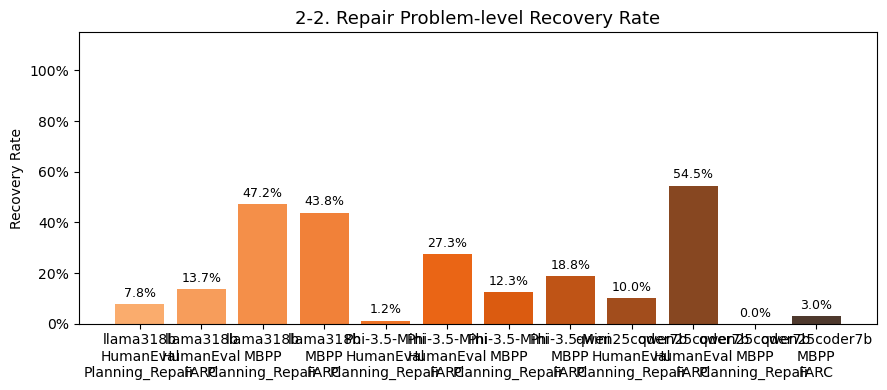

In [10]:
if not df_repair_prob.empty:
    fig, ax = plt.subplots(figsize=(9, 4))
    x = df_repair_prob.apply(lambda r: f"{r['Model']}\n{r['Dataset']}\n{r['Method']}", axis=1)
    bars = ax.bar(x, df_repair_prob["Problem-level Recovery Rate"],
                  color=sns.color_palette("Oranges_d", len(df_repair_prob)))
    ax.bar_label(bars, fmt="{:.1%}", padding=3, fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title("2-2. Repair Problem-level Recovery Rate", fontsize=13)
    ax.set_ylabel("Recovery Rate")
    plt.tight_layout()
    plt.show()
else:
    print("Repair problem-level 데이터가 없습니다.")

---
## 3. 전체 요약 테이블 (참고용)

In [11]:
summary_rows = []
for r in records:
    summary_rows.append({
        "Model"         : disp_model(r),
        "Dataset"       : disp_dataset(r),
        "Method"        : disp_method(r),
        "Total Problems": r.get("total_problems"),
        "Num Success"   : r.get("num_success"),
        "success@k"     : r.get("success_at_k"),
        "Avg Calls"     : r.get("avg_calls"),
    })

df_summary = (
    pd.DataFrame(summary_rows)
    .sort_values(["Model", "Dataset", "Method"])
    .reset_index(drop=True)
)
df_summary.style \
    .format({"success@k": "{:.2%}"}) \
    .background_gradient(subset=["success@k"], cmap="RdYlGn")

,Model,Dataset,Method,Total Problems,Num Success,success@k,Avg Calls
0,Phi-3.5-Mini,HumanEval,FARC,164,125,76.22%,nan
1,Phi-3.5-Mini,HumanEval,Planning,164,128,78.05%,7.914634
2,Phi-3.5-Mini,HumanEval,Planning_Repair,164,117,71.34%,9.048780
3,Phi-3.5-Mini,HumanEval,Repair,164,3,1.83%,19.652439
4,Phi-3.5-Mini,HumanEval,single_shot,164,2,1.22%,1.000000
5,Phi-3.5-Mini,MBPP,FARC,257,205,79.77%,nan
6,Phi-3.5-Mini,MBPP,Planning,257,200,77.82%,5.614786
7,Phi-3.5-Mini,MBPP,Planning_Repair,257,207,80.54%,5.354086
8,Phi-3.5-Mini,MBPP,Repair,257,179,69.65%,6.922179
9,Phi-3.5-Mini,MBPP,single_shot,257,163,63.42%,1.000000
